In [1]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import importlib
if 'src.data_processing' in sys.modules:
    import src.data_processing
    importlib.reload(src.data_processing)
if 'src.feature_engineering' in sys.modules:
    import src.feature_engineering
    importlib.reload(src.feature_engineering)
from src.data_processing import save_processed_data
from src.data_processing import load_processed_data
from src.feature_engineering import apply_all_features
from src.feature_engineering import encode_categorical_features

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:

# Wczytaj połączone dane
df_merged = load_processed_data("data/processed/merged_data.csv")

# fe
df_with_features = apply_all_features(df_merged)

# Podgląd
print("\nPierwsze wiersze:")
print(df_with_features.head())
print(f"\nNowe kolumny:")
new_cols = [col for col in df_with_features.columns if col not in df_merged.columns]
print(new_cols)


Wczytywanie danych z: C:\Users\aiszk\PycharmProjects\PythonProject\data\processed\merged_data.csv
✓ Wczytano 8,095,524 wierszy, 21 kolumn

FEATURE ENGINEERING
✓ Time features: 38 kolumn
✓ Lag features: dodano 3 opóźnień
✓ Rolling features: dodano 6 cech
✓ Weather features: dodano cechy pochodne
✓ Interaction features: dodano cechy interakcji

✓ Feature engineering zakończony
  Wymiary: 3,931,227 wierszy × 61 kolumn
  Braki danych: 0

Pierwsze wiersze:
        campus_id  meter_id           timestamp  consumption  \
122422          1         4 2018-01-02 18:15:00        3.260   
122423          1         4 2018-01-02 18:30:00        3.257   
122424          1         4 2018-01-02 18:45:00        3.288   
122425          1         4 2018-01-02 19:00:00        3.626   
122426          1         4 2018-01-02 19:15:00        3.882   

        campus_id_building  built_year   category  gross_floor_area  \
122422                   1      1967.0  mixed use         145558.14   
122423           

In [3]:
#  Zapisz dane z cechami

save_processed_data(df_with_features, "data/processed/features_data.csv")

✓ Dane zapisane do: C:\Users\aiszk\PycharmProjects\PythonProject\data\processed\features_data.csv


In [4]:
#  Analiza cech
print(f"\nStatystyki cech:")
print(df_with_features.describe())


Statystyki cech:
       campus_id      meter_id   consumption  campus_id_building  \
count  3931227.0  3.931227e+06  3.931227e+06           3931227.0   
mean         1.0  3.687762e+01  1.698478e+01                 1.0   
std          0.0  1.566791e+01  1.799478e+01                 0.0   
min          1.0  4.000000e+00 -2.279800e+01                 1.0   
25%          1.0  2.600000e+01  5.250000e+00                 1.0   
50%          1.0  3.600000e+01  1.125000e+01                 1.0   
75%          1.0  5.000000e+01  2.150000e+01                 1.0   
max          1.0  6.300000e+01  1.168750e+02                 1.0   

         built_year  gross_floor_area     room_area      capacity  \
count  3.931227e+06      3.931227e+06  3.931227e+06  3.931227e+06   
mean   1.965521e+03      1.255333e+06  5.551876e+03  6.795122e+02   
std    3.060879e+01      1.242719e+06  3.174106e+03  3.977084e+02   
min    1.899000e+03      4.249980e+03  3.705500e+02  8.000000e+00   
25%    1.967000e+03     

## Macierz korelacji i identyfikacja najbardziej skorelowanych cech

In [5]:
df_with_features.columns

Index(['campus_id', 'meter_id', 'timestamp', 'consumption',
       'campus_id_building', 'built_year', 'category', 'gross_floor_area',
       'room_area', 'capacity', 'name', 'capacity_campus',
       'apparent_temperature', 'air_temperature', 'dew_point_temperature',
       'relative_humidity', 'wind_speed', 'wind_direction', 'is_holiday',
       'is_semester', 'is_exam', 'hour', 'day_of_week', 'month',
       'day_of_month', 'week_of_year', 'quarter', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend',
       'is_night', 'is_morning', 'is_afternoon', 'is_evening',
       'consumption_lag_1h', 'consumption_lag_24h', 'consumption_lag_168h',
       'consumption_rolling_mean_3h', 'consumption_rolling_std_3h',
       'consumption_rolling_mean_6h', 'consumption_rolling_std_6h',
       'consumption_rolling_mean_24h', 'consumption_rolling_std_24h',
       'temperature_diff', 'humidity_level', 'wind_speed_squared',
       'consumption_per_sqm', 'consum

In [6]:
correlation_matrix = df_with_features.corr(method="spearman")
target_correlations = correlation_matrix['consumption'].sort_values(ascending=False)

print(target_correlations)


consumption                     1.000000
consumption_rolling_mean_3h     0.996071
consumption_lag_1h              0.991483
consumption_rolling_mean_6h     0.991358
consumption_rolling_mean_24h    0.960075
consumption_lag_24h             0.881670
consumption_lag_168h            0.859570
consumption_rolling_std_6h      0.615118
gross_floor_area                0.594162
consumption_rolling_std_24h     0.582906
consumption_rolling_std_3h      0.580761
room_area                       0.518538
capacity                        0.250877
decade_2010s                    0.234214
built_year                      0.228105
is_afternoon                    0.095290
air_temperature                 0.086310
day_sin                         0.081071
is_semester                     0.075615
apparent_temperature            0.067528
decade_1990s                    0.065950
wind_speed_squared              0.051912
wind_speed                      0.051912
is_morning                      0.043319
is_exam         

In [7]:
pochodne_targetu = ['consumption_lag_1h', 'consumption_lag_24h', 'consumption_lag_168h',
       'consumption_rolling_mean_3h', 'consumption_rolling_std_3h',
       'consumption_rolling_mean_6h', 'consumption_rolling_std_6h',
       'consumption_rolling_mean_24h', 'consumption_rolling_std_24h', 'consumption_per_sqm', 'consumption_per_person']

cols_for_corr = ['consumption'] + pochodne_targetu


spearman_corrs = df_with_features[cols_for_corr].corr(method='spearman')['consumption'].sort_values(ascending=False)

print(spearman_corrs)



consumption                     1.000000
consumption_rolling_mean_3h     0.996071
consumption_lag_1h              0.991483
consumption_rolling_mean_6h     0.991358
consumption_rolling_mean_24h    0.960075
consumption_lag_24h             0.881670
consumption_lag_168h            0.859570
consumption_rolling_std_6h      0.615118
consumption_rolling_std_24h     0.582906
consumption_rolling_std_3h      0.580761
Name: consumption, dtype: float64


## Wnioski:
- `'consumption_rolling_mean_3h` ma bardzo wysoką dodatnią korelację 0,996 — oznacza to, że średnia z ostatnich 3 godzin jest niemal idealnie monotonicznie powiązana z chwilową wartością zużycia (targetem).
`'
- `consumption_lag_1h `(poprzednia godzina) też bardzo silnie koreluje 0,991 — wartość sprzed godziny jest bardzo dobrą prognozą aktualnego zużycia.

- `consumption_rolling_mean_6h` i `consumption_rolling_mean_24h` także silnie korelują, ale korelacje spadają wraz z rosnącym oknem czasowym.

- Lags z dłuższego okresu, np. 24h i 168h, mają już niższe korelacje (odpowiednio ~0,88 i 0,86), co oznacza, że stale wpływają na target, ale mniej już bezpośrednio niż ostatnie godziny.

- Cechy takie jak odchylenia standardowe (`consumption_rolling_std_6h, consumption_rolling_std_24h, consumption_rolling_std_3h`) mają umiarkowaną korelację (~0,58-0,61), co wskazuje, że zmienność zużycia też ma pewną monotoniczną zależność z aktualnym zużyciem, ale jest mniej istotna niż średnie i lags.

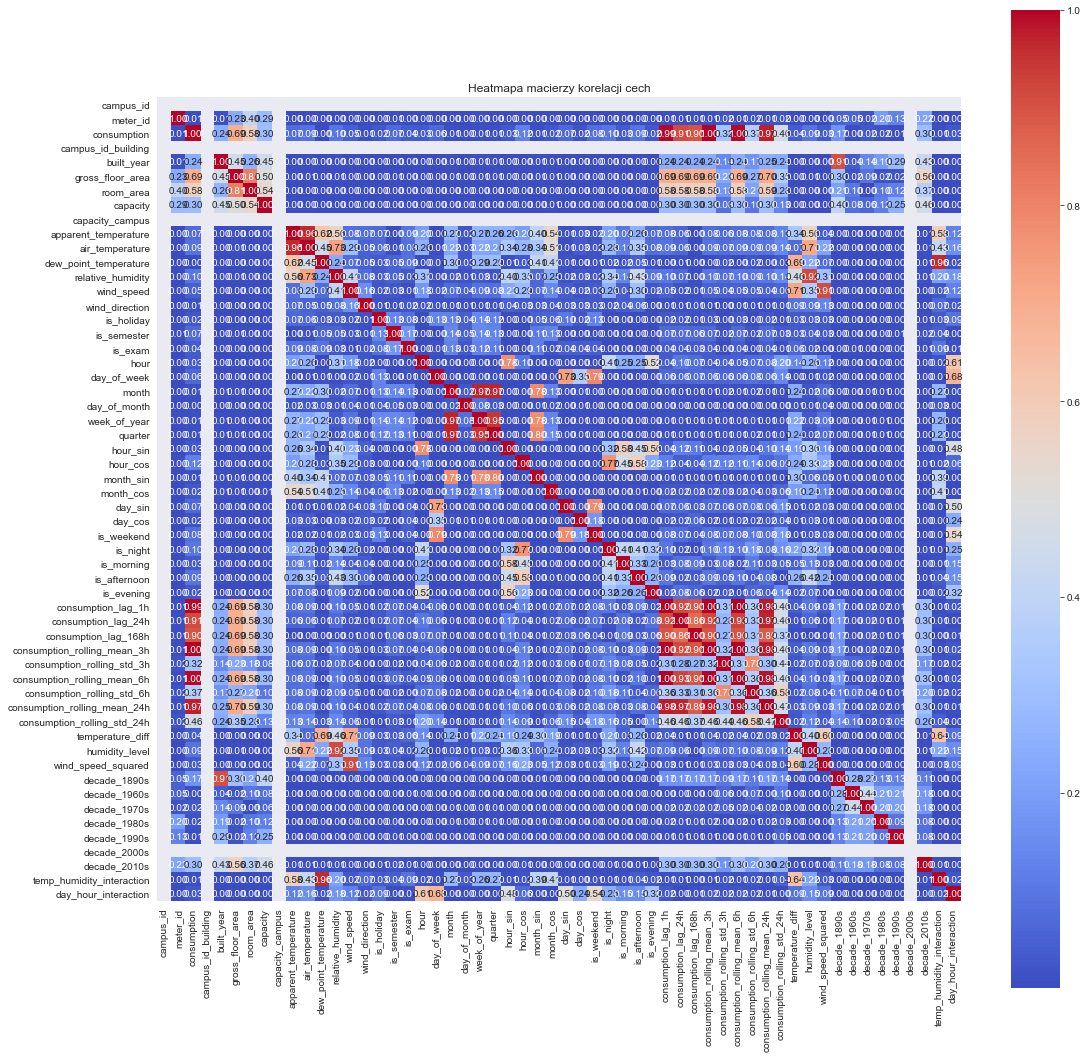

In [8]:
# Macierz absolutnej korelacji cech
corr_matrix_abs = df_with_features.corr().abs()

# Rysowanie heatmapy
plt.figure(figsize=(18, 18))
sns.heatmap(corr_matrix_abs, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmapa macierzy korelacji cech")
plt.show()

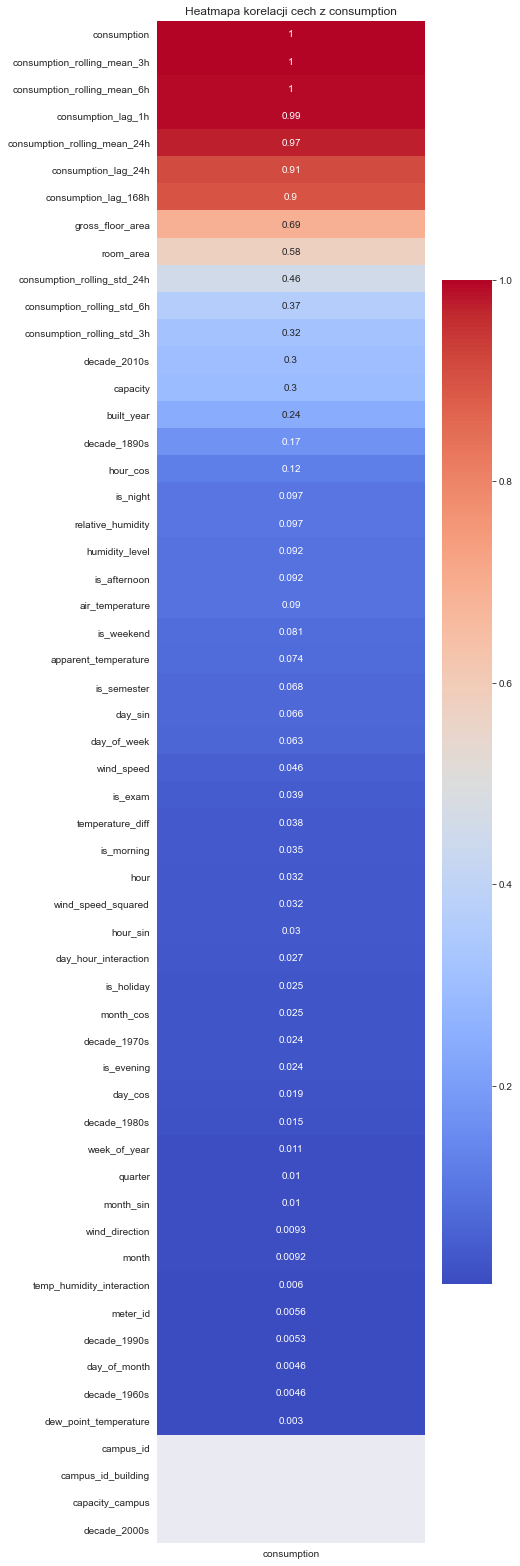

In [9]:
# korelacja z targetem

target = 'consumption'
corr_matrix = df_with_features.corr()
target_corr = corr_matrix[[target]].abs().sort_values(by=target, ascending=False)

plt.figure(figsize=(6, len(target_corr) / 2))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', cbar=True)
plt.title(f"Heatmapa korelacji cech z {target}")
plt.show()


In [10]:
# Macierz korelacji cech (absolutna wartość)
corr_matrix_abs = df_with_features.corr().abs()

# Górny trójkąt macierzy korelacji (bez przekątnej)
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

threshold = 0.9
to_pca = [col for col in upper.columns if any(upper[col] > threshold)]

print(f"Liczba cech do pca (korelacja > {threshold}): {len(to_pca)}")
print(to_pca)



Liczba cech do pca (korelacja > 0.9): 12
['air_temperature', 'week_of_year', 'quarter', 'consumption_lag_1h', 'consumption_lag_24h', 'consumption_rolling_mean_3h', 'consumption_rolling_mean_6h', 'consumption_rolling_mean_24h', 'humidity_level', 'wind_speed_squared', 'decade_1890s', 'temp_humidity_interaction']


## Redukcja wymiarowosci

In [11]:
X_pca = df_with_features[to_pca]

In [12]:
save_processed_data(X_pca, "data/processed/features_data_pca.csv")

✓ Dane zapisane do: C:\Users\aiszk\PycharmProjects\PythonProject\data\processed\features_data_pca.csv


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

In [14]:
pca = PCA(n_components=0.95, random_state=42)  # albo konkretna liczba składowych
X_pca_transformed = pca.fit_transform(X_scaled)

In [15]:
components_df = pd.DataFrame(
    data=pca.components_,
    columns=X_pca.columns
).T  # transpozycja dla lepszego odczytu - teraz cechy w wierszach

print("Macierz komponentów PCA (cechy × komponenty):")
print(components_df)


Macierz komponentów PCA (cechy × komponenty):
                                     0         1         2         3  \
air_temperature               0.063944  0.419373  0.493721  0.268125   
week_of_year                 -0.013278 -0.576085  0.267649  0.294313   
quarter                      -0.013010 -0.574115  0.268895  0.291741   
consumption_lag_1h            0.445343 -0.024211 -0.025879 -0.004372   
consumption_lag_24h           0.430014 -0.029907 -0.052112  0.006717   
consumption_rolling_mean_3h   0.445867 -0.024278 -0.025965 -0.004341   
consumption_rolling_mean_6h   0.446928 -0.023643 -0.024218 -0.004339   
consumption_rolling_mean_24h  0.447076 -0.024436 -0.029507 -0.000846   
humidity_level               -0.062347 -0.194627 -0.633623  0.293359   
wind_speed_squared            0.022995  0.030914  0.436582 -0.016595   
decade_1890s                 -0.096930  0.022333  0.035240 -0.048056   
temp_humidity_interaction     0.009648  0.346532 -0.116008  0.817086   

                 

In [28]:
# Wróć do poziomu projektu (jeden poziom wyżej)
os.chdir("..")

# Teraz zapisz
os.makedirs("data/processed", exist_ok=True)
components_df.to_csv("data/processed/pca_components.csv", index=True, index_label="feature")

# Sprawdzenie
filepath = os.path.abspath("data/processed/pca_components.csv")
print(f"✓ Plik zapisany do: {filepath}")

✓ Plik zapisany do: C:\Users\aiszk\PycharmProjects\PythonProject\data\processed\pca_components.csv


In [17]:
# dodajemy składowe główne do ramki
for i in range(X_pca_transformed.shape[1]):
    df_with_features[f"pca_{i+1}"] = X_pca_transformed[:, i]

In [18]:
df_with_features.drop(columns=to_pca, inplace=True)

In [19]:
save_processed_data(df_with_features, "data/processed/features_data_pca.csv")

✓ Dane zapisane do: C:\Users\aiszk\PycharmProjects\PythonProject\data\processed\features_data_pca.csv


In [20]:
#save_processed_data(df_with_features.head(4000), "data/processed/sample_pca.csv")

## One Hot Encoding

In [21]:
cat_cols = ["category",
            "name" ]

In [22]:
df_encoded = encode_categorical_features(df_with_features, cat_cols)

In [ ]:
df_encoded.drop(columns=id_cols, inplace=True)

In [ ]:
save_processed_data(df_encoded, "data/processed/features_data_encoded.csv")

In [ ]:
df_encoded.columns